# 02 · EDA — which narratives survive contact with the data?

Quick, deliberately plain charts (matplotlib defaults) for every story question. Nothing here is styled; the point is
to decide **what the charts should say** before designing them. Each section ends with a verdict: ✅ holds,
⚠️ partly, ❌ contradicted.

In [1]:
import sys; sys.path.insert(0, '..')
import json, pandas as pd, matplotlib.pyplot as plt
from src import config, features
t = features.load_tables(); facts = json.loads(config.FACTS.read_text())
r = t['results']; gp = r[r.session == 'gp'].sort_values('date').reset_index(drop=True)
plt.rcParams.update({'figure.figsize': (10, 3.2), 'figure.dpi': 80})

## Ch.1 · The whole career at a glance

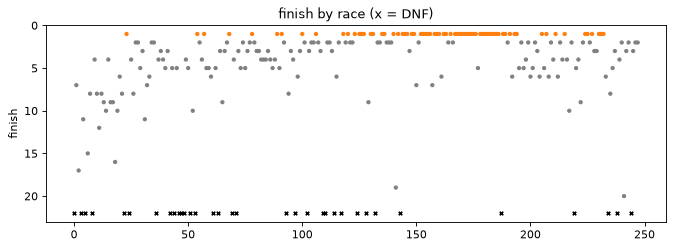

,starts,wins,podiums,not_classified,fastest_qualifier,win_pct
2015,19.0,0.0,0.0,4.0,0.0,0.0
2016,21.0,1.0,7.0,3.0,0.0,4.8
2017,20.0,2.0,4.0,7.0,0.0,10.0
2018,21.0,2.0,11.0,4.0,0.0,9.5
2019,21.0,3.0,9.0,2.0,3.0,14.3
2020,17.0,2.0,11.0,5.0,1.0,11.8
2021,22.0,10.0,18.0,3.0,8.0,45.5
2022,22.0,15.0,17.0,1.0,8.0,68.2
2023,22.0,19.0,21.0,0.0,13.0,86.4
2024,24.0,9.0,14.0,1.0,10.0,37.5


In [2]:
fig, ax = plt.subplots()
ax.scatter(gp.index, gp.position.where(gp.classified), s=8, c=(gp.position_text == '1').map({True: 'C1', False: 'gray'}))
ax.scatter(gp.index[~gp.classified], [22] * (~gp.classified).sum(), marker='x', c='k', s=10)
ax.invert_yaxis(); ax.set(title='finish by race (x = DNF)', ylabel='finish'); plt.show()
pd.DataFrame(facts['by_season']).T

✅ **Clear three-act shape**: midfield scatter (2015–2017), podium-level (2018–2020), a solid band at P1
(2021–2024), still top-3 in 2025, then a scattered 2026. The timeline alone tells the story, which makes it a good hero chart.

## Ch.2 · #33 — the rise: teammates

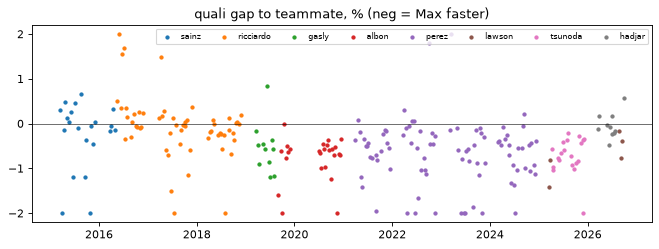

,first,n_quali,median_gap_pct,quali_ahead_share,n_race,race_ahead_share
teammate_id,,,,,,
sainz,2015-03-15,21,-0.059,0.571,12.0,0.500
ricciardo,2016-05-15,57,-0.050,0.579,33.0,0.606
gasly,2019-03-17,11,-0.566,0.909,11.0,0.909
albon,2019-09-01,25,-0.618,0.960,18.0,0.889
perez,2021-03-28,88,-0.524,0.920,75.0,0.920
lawson,2025-03-16,5,-0.770,1.000,3.0,1.000
tsunoda,2025-04-06,20,-0.686,1.000,20.0,1.000
hadjar,2026-03-15,10,-0.101,0.700,8.0,0.875


In [3]:
q = t['qualifying'].dropna(subset=['gap_pct']).sort_values('date')
fig, ax = plt.subplots()
for k, g in q.groupby('teammate_id', sort=False): ax.scatter(g.date, g.gap_pct.clip(-2, 2), s=8, label=k)
ax.axhline(0, c='k', lw=.5); ax.legend(ncol=8, fontsize=7); ax.set(title='quali gap to teammate, % (neg = Max faster)'); plt.show()
features.teammate_summary(t['qualifying'], r).round(3)

⚠️ **More interesting than "he crushed every teammate".** Against **Sainz** and **Ricciardo** qualifying was close
(median gap ≈ 0.05–0.06 %, he out-qualified them only ~57–58 % of the time; Ricciardo matched him in races too).
From 2019 on, the gap to every teammate is ~0.5–0.8 %. **And in 2026 Hadjar is the closest teammate since Ricciardo**
(median ≈ 0.10 %). Candidate title: *"Early teammates kept up. Then nobody did, until 2026."*

## Ch.3 · Title fights

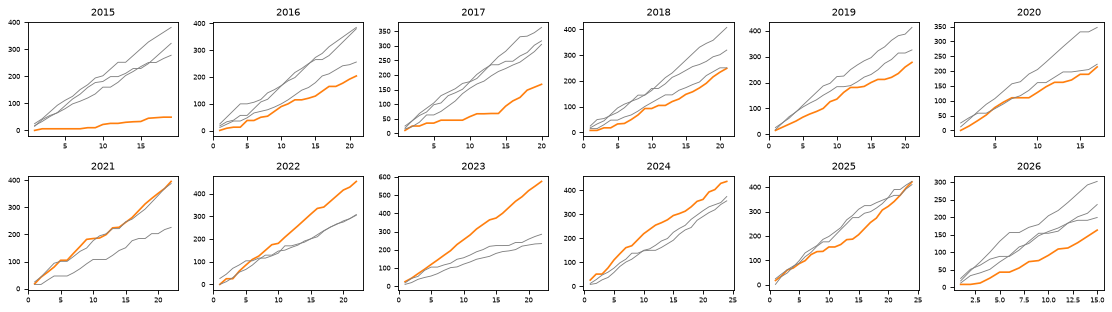

,final_gap,best_rival,rounds_leading,rounds
2015,-332.0,hamilton,0,19
2016,-181.0,rosberg,0,21
2017,-195.0,hamilton,0,20
2018,-159.0,hamilton,0,21
2019,-135.0,hamilton,0,21
2020,-133.0,hamilton,0,17
2021,8.0,hamilton,14,22
2022,146.0,leclerc,17,22
2023,290.0,perez,22,22
2024,63.0,norris,24,24


In [4]:
st = t['standings']; fig, axes = plt.subplots(2, 6, figsize=(14, 4), sharey=False); axes = axes.ravel()
for ax, (s, x) in zip(axes, st.groupby('season')):
    top = x[x['round'] == x['round'].max()].nsmallest(3, 'rank').driver_id.tolist()
    for d in set(top) | {config.DRIVER_ID}:
        y = x[x.driver_id == d]; ax.plot(y['round'], y.points_cum, c='C1' if d == config.DRIVER_ID else 'gray', lw=1.5 if d == config.DRIVER_ID else .8)
    ax.set_title(s, fontsize=9); ax.tick_params(labelsize=6)
plt.tight_layout(); plt.show()
pd.DataFrame(facts['title_fights']).T

✅ **Two decided by single digits:** 2021 won by 8 points, and **2025 lost by 2 points** to Norris. The 2025 near-miss
isn't part of the popular "reign" narrative and should be. 2023 and 2024: led after every round.
Candidate title: *"Four titles, two knife-edges: +8 in 2021, −2 in 2025."*

## Ch.4 · #1 — how dominant was dominant?

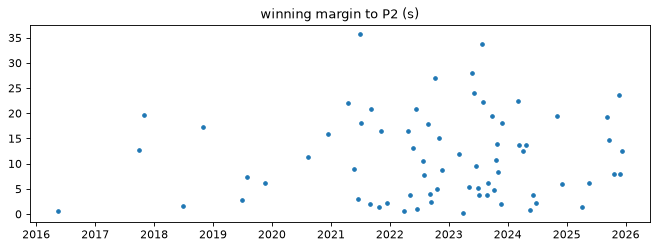

season  2016   2017  2018  2019   2020   2021   2022   2023   2024   2025
size    1.00   2.00  2.00  3.00   2.00  10.00  15.00  19.00   9.00   8.00
median  0.62  16.22  9.41  6.08  13.65  12.76   8.77   9.57  12.54  10.29


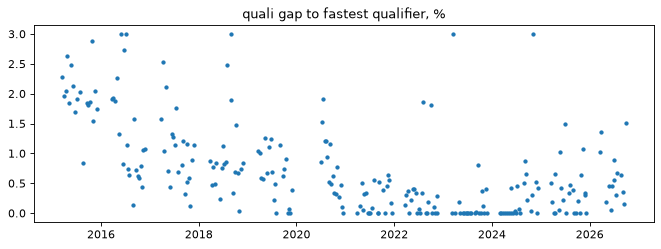

In [5]:
wm = t['win_margins']; fig, ax = plt.subplots()
ax.scatter(wm.date, wm.margin_s, s=10); ax.set(title='winning margin to P2 (s)'); plt.show()
print(wm.groupby('season').margin_s.agg(['size', 'median']).round(2).T)
pg = t['pole_gap']; fig, ax = plt.subplots(); ax.scatter(pg.date, pg.gap_to_fastest_pct.clip(upper=3), s=8)
ax.set(title='quali gap to fastest qualifier, %'); plt.show()

⚠️ **Winning margin is a weak dominance measure.** 2023's median margin is *not* larger than 2021's: once far ahead,
a leader manages the gap instead of maximising it. Margin mostly counts *how often* he won, not *by how much*.
→ The lap-pace **dominance index** (clean-lap median vs best rival, computed when the lap download finishes) is the right C07.
The winning-margin chart is dropped; its best facts survive in prose.

✅ **Gap to the fastest qualifier** shows the arc cleanly: season median ~1.9 % in 2015 → **0.00 % in 2023** → rising again
in 2025 and 2026. This is the spine for C09.

## Ch.5 · Signature race candidates

In [6]:
gp.nlargest(6, 'positions_gained')[['season','race_name','grid','position','positions_gained']]

,season,race_name,grid,position,positions_gained
133,2021,Russian Grand Prix,20,2,18.0
77,2018,United States Grand Prix,18,2,16.0
205,2024,São Paulo Grand Prix,17,1,16.0
229,2025,São Paulo Grand Prix,19,3,16.0
75,2018,Russian Grand Prix,19,5,14.0
233,2026,Australian Grand Prix,20,6,14.0


Candidates (data available for all): **2021 Abu Dhabi** (title decider, 4 stints, SC at the end), **2024 São Paulo**
(wet, won from grid 17, the furthest back of any of his wins), 2016 Spain (first win; Jolpica lap positions only).
2024 São Paulo is the strongest single-race *visual*: a 17 → 1 climb on the position-by-lap chart is dramatic.
2021 Abu Dhabi is the strongest *story*, but the result was decided by a late safety-car decision; I'd recommend it only if
the chart can explain that neutrally.

## Ch.6 · Among the greats

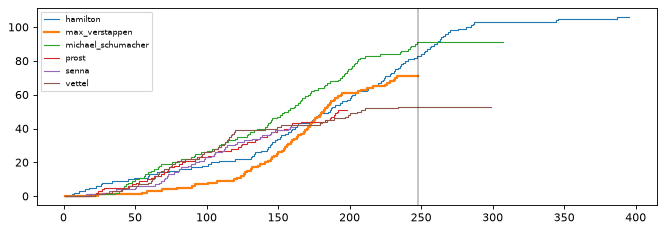

,name,starts,wins,wins_after_same_starts,best_50_start_window_wins,best_100_start_window_wins
hamilton,Lewis Hamilton,395,106,83,31,55
max_verstappen,Max Verstappen,248,71,71,39,56
michael_schumacher,Michael Schumacher,307,91,91,31,54
prost,Alain Prost,198,51,51,18,33
senna,Ayrton Senna,161,41,41,23,35
vettel,Sebastian Vettel,299,53,53,23,39


In [7]:
cg = t['career_greats']; fig, ax = plt.subplots()
for d, g in cg.groupby('driver_id'): ax.step(g.start_n, g.wins_cum, where='post', label=d, lw=2 if d == config.DRIVER_ID else 1)
ax.axvline(facts['career']['starts'], c='k', lw=.4); ax.legend(fontsize=7); plt.show()
pd.DataFrame(facts['greats']).T

❌/⚠️ **The popular "most dominant ever" line does not hold on wins-per-start.** At the same number of starts
(248), **Schumacher had 91 wins and Hamilton 83**, against his 71. What *is* true: his **best 50-start stretch had 39 wins**, against 31
for both Hamilton and Schumacher (checked below). Over 100 starts the three are level (56 / 55 / 54), so the claim must
say 50. Candidate title: *"Fewer wins per start than Schumacher or Hamilton, but the best 50-race run of any of them."*

In [8]:
pd.DataFrame(facts['greats']).T[['starts','wins','wins_after_same_starts','best_50_start_window_wins','best_100_start_window_wins']]

,starts,wins,wins_after_same_starts,best_50_start_window_wins,best_100_start_window_wins
hamilton,395,106,83,31,55
max_verstappen,248,71,71,39,56
michael_schumacher,307,91,91,31,54
prost,198,51,51,18,33
senna,161,41,41,23,35
vettel,299,53,53,23,39


## Ch.7 · #3 — the reset (2026)

In [9]:
s26 = gp[gp.season == facts['data_cutoff']['season']]
s26[['round','race_name','grid','position_text','teammate_id','teammate_position_text']]

,round,race_name,grid,position_text,teammate_id,teammate_position_text
233,1,Australian Grand Prix,20,6,hadjar,R
234,2,Chinese Grand Prix,8,R,hadjar,8
235,3,Japanese Grand Prix,11,8,hadjar,12
236,4,Miami Grand Prix,2,5,hadjar,R
237,5,Canadian Grand Prix,6,3,hadjar,5
238,6,Monaco Grand Prix,2,R,hadjar,3
239,7,Barcelona Grand Prix,5,4,hadjar,6
240,8,Austrian Grand Prix,5,2,hadjar,6
241,9,British Grand Prix,7,20,hadjar,5
242,10,Belgian Grand Prix,2,3,hadjar,6


⚠️ **"Red Bull has struggled" is half right.** No wins in 15 races and 6th in the standings, with the lowest
qualifying pace relative to the front since 2020. But the finishing trend is **upward**: P3, P2, P2 in the last three
finishes. The honest chapter: *"No wins yet, but the gap is closing,"* dated with the cut-off.

## Chart shortlist after EDA
| Chart | Keep? | Note |
|---|---|---|
| C01 every race | ✅ hero | three-act shape is obvious |
| C02 title races | ✅ | highlight 2021 (+8) and 2025 (−2) |
| C03 teammate gap | ✅ | the story is "close early, gap later, closer again in 2026" |
| C04 grid → flag | ✅ | dumbbell of top comebacks + strip of all gains |
| C05 circuits in color | ✅ | pick 4–6 of his most-won tracks (2018+) |
| C06 telemetry duel | ✅ | session TBD from candidates |
| C07 dominance index | ✅ lap-pace version | winning-margin version dropped (see Ch.4) |
| C08 signature race | ✅ | 2024 São Paulo recommended |
| C09 reset | ✅ | quali gap to fastest + race pace + finishes |
| Tier 2 | C10 greats ✅, C11 season fingerprints ✅, C12 world map ✅, C13 DNF anatomy ✅ (2024+ = cause not recorded), C14 lap-one gains (lap data) ✅ | |
